In [ ]:
import pandas as pd
import numpy as np

import scipy.stats as stats #use for normality test this use for plot qqplot

import matplotlib.pyplot as plt #use for data visualization
import seaborn as sns #use for data visualization

from sklearn.model_selection import train_test_split #use for splitting the data into training and testing sets
from sklearn.metrics import accuracy_score #use for evaluating the performance of the model
from sklearn.model_selection import cross_val_score #use for evaluating the performance of the model using cross-validation

from sklearn.linear_model import LogisticRegression #use for building a logistic regression model
from sklearn.tree import DecisionTreeClassifier #use for building a decision tree classifier model

from sklearn.preprocessing import FunctionTransformer #use for applying a function to the data
from sklearn.preprocessing import StandardScaler #use for standardizing the data
from sklearn.compose import ColumnTransformer #use for applying different transformations to different columns of the data
from sklearn.pipeline import Pipeline #use for creating a pipeline of transformations and a model

In [3]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True) #use inplace=True to fill the missing values in the original dataframe
#if we use inplace=False then it will return a new dataframe with the missing values filled but it will not change the original dataframe

C:\Users\INDIAN\AppData\Local\Temp\ipykernel_19932\762957104.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True) #use inplace=True to fill the missing values in the original dataframe


In [11]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [15]:
X = df.iloc[:,1:3]#all the rows and columns from index 1 to 2 (age and fare)
y = df.iloc[:,0]#output variable (survived)

In [23]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42) 

C:\Users\INDIAN\AppData\Local\Temp\ipykernel_19932\3769680820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])#plot the distribution of the age variable in the training set using seaborn's distplot function


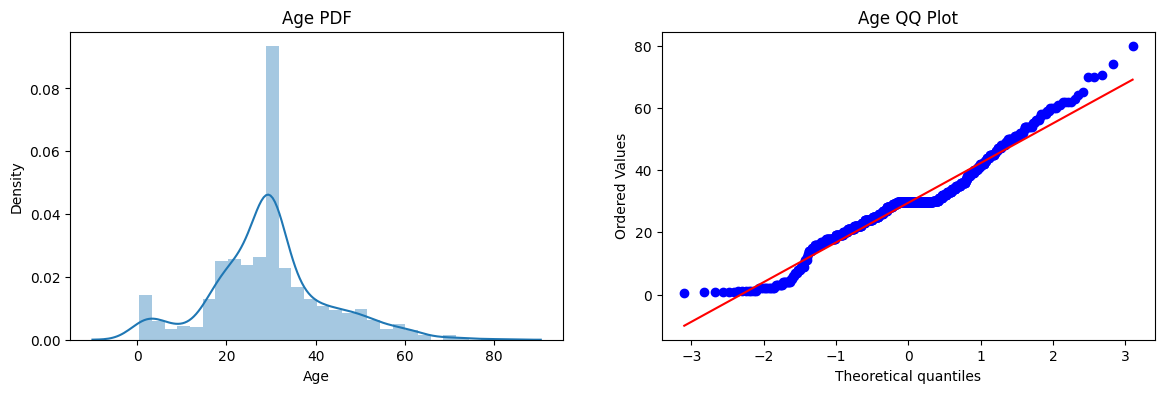

In [17]:
plt.figure(figsize=(14,4))#figure size for the plots 14 inches wide and 4 inches high
plt.subplot(121)#subplot for the first plot (age pdf) 121 means 1 row and 2 columns and this is the first plot
sns.distplot(X_train['Age'])#plot the distribution of the age variable in the training set using seaborn's distplot function
plt.title('Age PDF')#title for the first plot (age pdf)

plt.subplot(122)#subplot for the second plot (age qq plot) 122 means 1 row and 2 columns and this is the second plot
stats.probplot(X_train['Age'], dist="norm", plot=plt)#plot the qq plot for the age variable in the training set using scipy's probplot function with the normal distribution as the reference distribution and matplotlib's plot function to plot the qq plot
plt.title('Age QQ Plot')

plt.show()

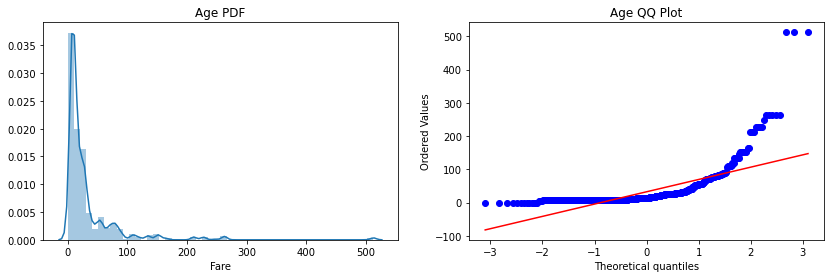

In [245]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [18]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [24]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


In [26]:
trf = FunctionTransformer(func=np.log1p)#use for applying the log transformation to the data using numpy's log1p function which is log(1+x) to handle the zero values in the data
#np.log simply apply the log transformation to the data but it will give an error if there are zero values in the data because log(0) is undefined but np.log1p will handle the zero values by adding 1 to the data before applying the log transformation

In [27]:
X_train_transformed = trf.fit_transform(X_train)#fit_transform method is used to fit the transformer to the training data and then transform the training data using the fitted transformer
X_test_transformed = trf.transform(X_test)#only use the trasform  in the test data because we have already fitted the transformer to the training data and we want to apply the same transformation to the test data

In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6815642458100558


In [250]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6599875156054932


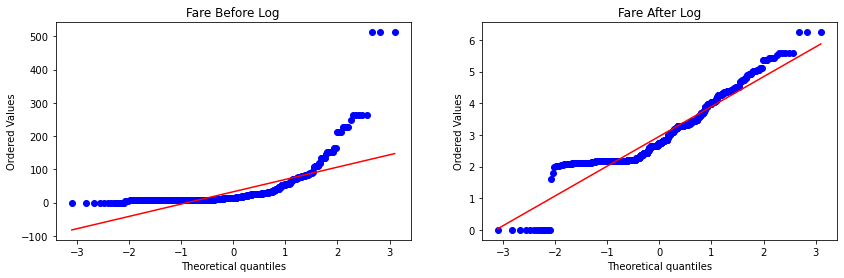

In [251]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

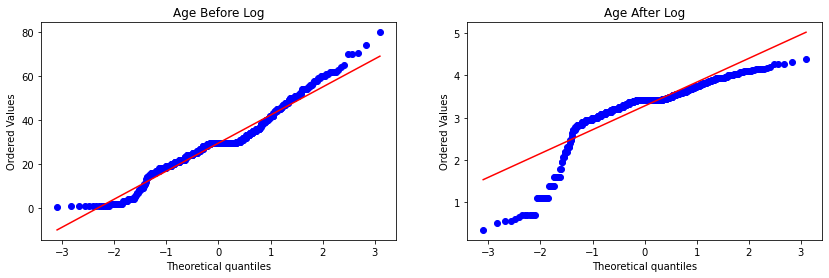

In [252]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [253]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [254]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972


In [255]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6599750312109862


In [234]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6195131086142323


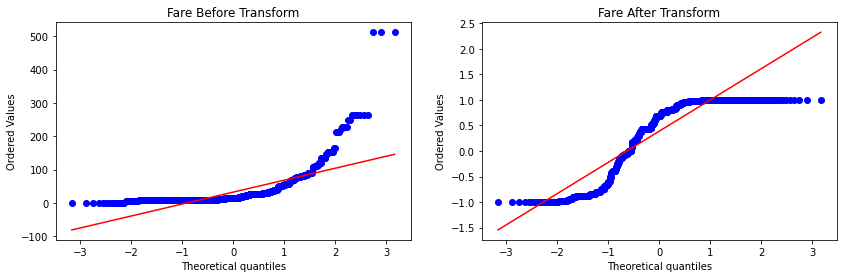

In [265]:
apply_transform(np.sin)